# Spectroscopic follow-up of ASAS-SN ellipsoidal variables

We did a systematic survey for ellipsoidal variables back in 2020:

https://ui.adsabs.harvard.edu/abs/2021MNRAS.507..104R/abstract

We detected >300 systems, and performed spectroscopic follow-up of a dozen or so targets in the following years. Now we can fit the orbits and try to characterize the companions. 

This notebooks walks through getting the ASAS-SN light curves, measuring the orbital period, and downloading the RVs. 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from astroquery.vizier import Vizier
from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy.timeseries import LombScargle

try:
    from pyasassn.client import SkyPatrolClient
    client = SkyPatrolClient(verbose=True)
except:
    print('No connection to SkyPatrolClient')
    
def plotparams(ax, labelsize=15):
    '''
    Basic plot params

    :param ax: axes to modify

    :type ax: matplotlib axes object

    :returns: modified matplotlib axes object
    '''
    ax.minorticks_on()
    ax.yaxis.set_ticks_position('both')
    ax.xaxis.set_ticks_position('both')
    ax.tick_params(direction='in', which='both', labelsize=labelsize)
    ax.tick_params('both', length=8, width=1.8, which='major')
    ax.tick_params('both', length=4, width=1, which='minor')
    for axis in ['top', 'bottom', 'left', 'right']:
        ax.spines[axis].set_linewidth(1.5)
    return ax
    

Welcome to ASAS-SN Skypatrol!

Current Deployment Version: 0.6.19 (22 MAY 2025)
Please upgrade your client if not up to date.

We are reprocessing a number of lightcurves in database.
Once finished we should have more complete and higher quality photometry.
Thank you for your patience,
K. Hart (22 MAY 2025)




In [2]:
# Here are some Gaia DR3 Source IDs to get started
source_ids = [6442307187151771904, 3008730182621791488, 4887016447422335232]

source = source_ids[0]

In [3]:
#Need to get RA and DEC to query asassn
r = Vizier(catalog="I/355/gaiadr3", columns=['Source', 'RA_ICRS', 'DE_ICRS'])
r = r.query_constraints(Source=str(source))[0]

if len(r):
    r = r.to_pandas().iloc[0].to_dict()
    ra = r['RA_ICRS']
    dec = r['DE_ICRS']
else:
    print('Gaia DR3 Query Failed')

Pulled 1 of 1


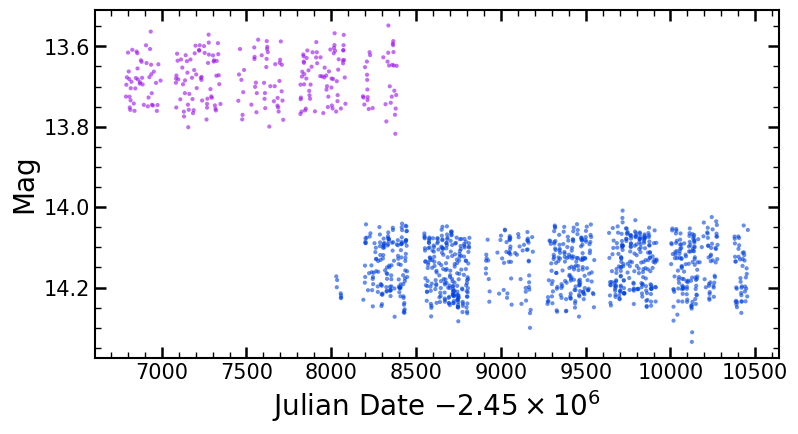

In [4]:
#Query ASASSN

#First get the asas_sn_id
result = client.cone_search(ra, dec, radius=5, units='arcsec', catalog='stellar_main')
if len(result) == 0:
    print('No ASAS-SN target found')
    asas_sn_id = None
elif len(result) == 1:
    asas_sn_id = int(result.asas_sn_id.iloc[0])
else:
    #Results won't be sorted by distance to target
    c1 = SkyCoord(ra, dec)
    c2 = SkyCoord(result.ra_deg.to_numpy()*u.deg, result.dec_deg.to_numpy()*u.deg)
    separation = c1.separation(c2)
    idx = np.argmin(separation)
    asas_sn_id = int(result.asas_sn_id.iloc[idx])

if asas_sn_id is not None:
    lc = client.query_list(asas_sn_id, catalog='stellar_main', download=True)
    df = lc.data
    dfv = df[(df.phot_filter == 'V') & (df.quality == 'G')].reset_index(drop=True)
    dfg = df[(df.phot_filter == 'g') & (df.quality == 'G')].reset_index(drop=True)
    
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
fig.subplots_adjust(top=.98, right=.98)
ax = plotparams(ax)

ax.scatter(dfv.jd-2.45e6, dfv.mag, color='xkcd:violet', marker='.', edgecolor='none', alpha=0.6)
ax.scatter(dfg.jd-2.45e6, dfg.mag, color='xkcd:blue', marker='.', edgecolor='none', alpha=0.6)

ax.set_xlabel(r'Julian Date $-2.45\times10^6$', fontsize=20)
ax.set_ylabel('Mag', fontsize=20)
ax.invert_yaxis()

Text(0, 0.5, 'Power')

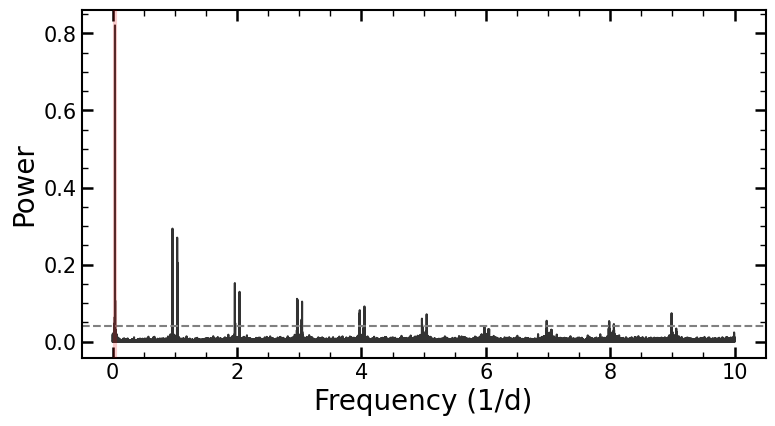

In [22]:
ls = LombScargle(dfg.jd.values, dfg.mag.values)
fal = ls.false_alarm_level(1e-5)

ls_freq, ls_power = ls.autopower(minimum_frequency=1/500, maximum_frequency=10, samples_per_peak=100)

fig, ax = plt.subplots(1, 1, figsize=(8, 4))
fig.subplots_adjust(top=.98, right=.98)
ax = plotparams(ax)

ax.plot(ls_freq, ls_power, color='black', zorder=2, alpha=0.8)
ax.axhline(fal, color='gray', ls='--')

idx = np.argmax(ls_power)
ax.axvline(ls_freq[idx], color='xkcd:red', lw=3, alpha=0.2, zorder=3)

ax.set_xlabel('Frequency (1/d)', fontsize=20)
ax.set_ylabel('Power', fontsize=20)

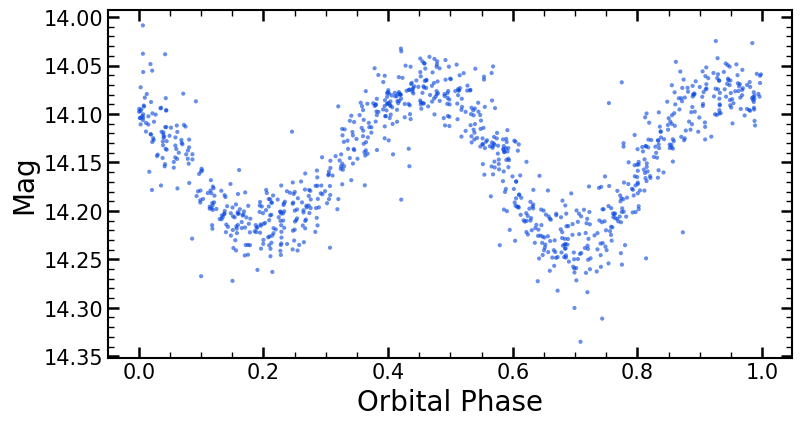

In [23]:
#Phase fold and plot light curve

period = 2 * 1/ls_freq[idx]
dfg['phase'] = (dfg.jd.values % period) / period

fig, ax = plt.subplots(1, 1, figsize=(8, 4))
fig.subplots_adjust(top=.98, right=.98)
ax = plotparams(ax)

ax.scatter(dfg.phase, dfg.mag, color='xkcd:blue', marker='.', edgecolor='none', alpha=0.6)

ax.set_xlabel('Orbital Phase', fontsize=20)
ax.set_ylabel('Mag', fontsize=20)
ax.invert_yaxis()

In [24]:
# Query radial velocities
sheet_id = "1HTfWOxoEv6Wbihk5u4zed2ym_XjqWQWFThDGgJdUetA"
gid = "205093247"
df_rvs = pd.read_csv(f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?gid={gid}&format=csv")

df_rvs = df_rvs[df_rvs.Source == str(source)].reset_index(drop=True).drop(columns=['Helper'])
df_rvs

,Source,JD,RV1,RV1_err,Instrument,Path
0,6442307187151771904,2459336.837,-78.08,0.113901,CHIRON,achi210501.1165.fits
1,6442307187151771904,2459344.929,-89.41,0.099560,CHIRON,achi210509.1182.fits
2,6442307187151771904,2459350.938,-74.22,0.086839,CHIRON,achi210515.1169.fits
3,6442307187151771904,2459356.865,-48.75,0.085198,CHIRON,achi210521.1173.fits
4,6442307187151771904,2459360.774,-29.91,0.080061,CHIRON,achi210525.1171.fits
5,6442307187151771904,2459364.904,-14.64,0.053853,CHIRON,achi210529.1171.fits
6,6442307187151771904,2459369.827,-6.69,0.050567,CHIRON,achi210603.1158.fits
7,6442307187151771904,2459374.724,-12.03,0.056499,CHIRON,achi210608.1155.fits
8,6442307187151771904,2459379.750,-29.14,0.049087,CHIRON,achi210613.1163.fits
9,6442307187151771904,2459382.779,-45.18,0.114144,CHIRON,achi210616.1165.fits


Text(0, 0.5, 'Radial Velocity [km/s]')

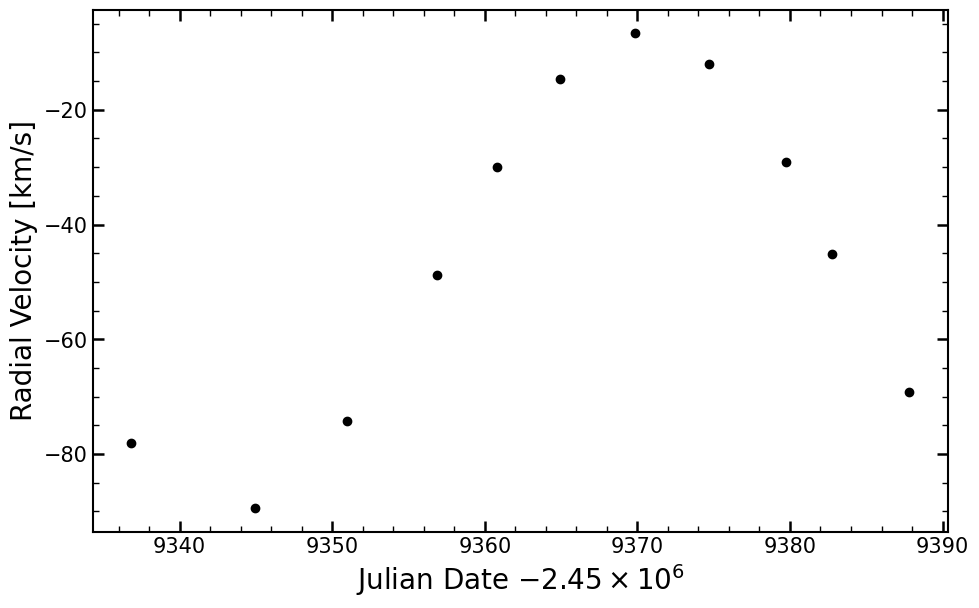

In [25]:
# Plot RV data

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
fig.subplots_adjust(top=.98, right=.98)
ax = plotparams(ax)

ax.scatter(df_rvs.JD - 2.45e6, df_rvs.RV1, marker='o', color='black')

ax.set_xlabel(r'Julian Date $-2.45 \times 10^6$', fontsize=20)
ax.set_ylabel('Radial Velocity [km/s]', fontsize=20)